# AI Lab Report Notebook
## Comparing SmartSeq and DropSeq gene expression data

In this notebook, I will explore the gene expression datasets from the AI Lab assignment.

The main goals are:
- understand what files are available
- explore the raw and processed data
- compare SmartSeq and DropSeq
- compare MCF7 and HCC1806
- look at data structure using PCA and clustering
- try a simple classifier on the normalized training data

I will keep the analysis simple and clear, since this is more of a test.

## 1. Import the libraries

In [87]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

## 2. Set the paths

In [88]:
BASE = Path(r"C:\Users\hugoo\OneDrive\Desktop\ai-lab-report\data")

SMART = BASE / "SmartSeq"
DROP = BASE / "DropSeq"

print("SmartSeq folder exists:", SMART.exists())
print("DropSeq folder exists:", DROP.exists())

SmartSeq folder exists: True
DropSeq folder exists: True


## 3. Check the files inside the folders

In [89]:
print("SMARTSEQ FILES")
for f in sorted(SMART.glob("*")):
    print("-", f.name)

print("\nDROPSEQ FILES")
for f in sorted(DROP.glob("*")):
    print("-", f.name)

SMARTSEQ FILES
- HCC1806_SmartS_Filtered_Data.txt
- HCC1806_SmartS_Filtered_Normalised_3000_Data_test_anonim.txt
- HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt
- HCC1806_SmartS_MetaData.tsv
- HCC1806_SmartS_Unfiltered_Data.txt
- MCF7_SmartS_Filtered_Data.txt
- MCF7_SmartS_Filtered_Normalised_3000_Data_test_anonim.txt
- MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt
- MCF7_SmartS_MetaData.tsv
- MCF7_SmartS_Unfiltered_Data.txt

DROPSEQ FILES
- HCC1806_Filtered_Normalised_3000_Data_test_anonim.txt
- HCC1806_Filtered_Normalised_3000_Data_train.txt
- MCF7_Filtered_Normalised_3000_Data_test_anonim.txt
- MCF7_Filtered_Normalised_3000_Data_train.txt


## 4. Some helper functions

In [90]:
def load_expr(path):
    """
    Load a gene expression matrix where:
    - rows are genes
    - columns are cells/samples
    """
    df = pd.read_csv(path, sep=r"\s+", engine="python", index_col=0)
    
    # remove quotes from gene names and sample names if they exist
    df.index = df.index.astype(str).str.replace('"', '', regex=False)
    df.columns = df.columns.astype(str).str.replace('"', '', regex=False)
    
    return df


def dataset_summary(expr, dataset_name):
    """
    Basic summary of one expression matrix.
    """
    return pd.DataFrame({
        "dataset": [dataset_name],
        "n_genes": [expr.shape[0]],
        "n_samples": [expr.shape[1]],
        "mean_value": [expr.values.mean()],
        "median_value": [np.median(expr.values)],
        "zero_fraction": [(expr.values == 0).mean()]
    })


def sample_qc(expr):
    """
    QC summary per sample/cell.
    """
    total_counts = expr.sum(axis=0)
    detected_genes = (expr > 0).sum(axis=0)
    zero_fraction = (expr == 0).sum(axis=0) / expr.shape[0]
    
    return pd.DataFrame({
        "total_counts": total_counts,
        "detected_genes": detected_genes,
        "zero_fraction": zero_fraction
    })


def gene_qc(expr):
    """
    QC summary per gene.
    """
    mean_expression = expr.mean(axis=1)
    detected_samples = (expr > 0).sum(axis=1)
    zero_fraction = (expr == 0).sum(axis=1) / expr.shape[1]
    
    return pd.DataFrame({
        "mean_expression": mean_expression,
        "detected_samples": detected_samples,
        "zero_fraction": zero_fraction
    })


def plot_hist(series, title, xlabel, bins=40):
    plt.figure(figsize=(7, 4))
    plt.hist(series, bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.show()


def pca_plot(expr, labels=None, title="PCA plot"):
    """
    PCA on samples (columns).
    """
    X = expr.T.copy()  # samples x genes
    
    # standardize features
    X_scaled = StandardScaler().fit_transform(X)
    
    pca = PCA(n_components=2, random_state=42)
    pcs = pca.fit_transform(X_scaled)
    
    plot_df = pd.DataFrame({
        "PC1": pcs[:, 0],
        "PC2": pcs[:, 1]
    }, index=X.index)
    
    plt.figure(figsize=(7, 5))
    
    if labels is None:
        plt.scatter(plot_df["PC1"], plot_df["PC2"], s=25)
    else:
        plot_df["label"] = labels.loc[plot_df.index].values
        sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="label", s=40)
    
    plt.title(title)
    plt.show()
    
    print("Explained variance ratio:", pca.explained_variance_ratio_)


def top_variable_genes(expr, top_n=50):
    """
    Get the most variable genes.
    """
    gene_var = expr.var(axis=1).sort_values(ascending=False)
    return gene_var.head(top_n).index


def heatmap_top_variable_genes(expr, labels=None, top_n=30, title="Top variable genes heatmap"):
    genes = top_variable_genes(expr, top_n=top_n)
    sub = expr.loc[genes]
    
    # standardize each gene for easier visual comparison
    sub_z = sub.sub(sub.mean(axis=1), axis=0).div(sub.std(axis=1).replace(0, 1), axis=0)
    
    plt.figure(figsize=(12, 7))
    sns.heatmap(sub_z, cmap="vlag", center=0)
    plt.title(title)
    plt.xlabel("Samples")
    plt.ylabel("Genes")
    plt.show()

## 5. Load the main datasets

Now I load the files I want to work with.

SmartSeq:
- unfiltered
- filtered
- normalized train
- metadata

DropSeq:
- normalized train

I start with the training files because they already have the real labels and are enough for exploration and simple modeling.

In [91]:
# SMARTSEQ
smart_mcf7_unfiltered = load_expr(SMART / "MCF7_SmartS_Unfiltered_Data.txt")
smart_mcf7_filtered = load_expr(SMART / "MCF7_SmartS_Filtered_Data.txt")
smart_mcf7_norm_train = load_expr(SMART / "MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt")

smart_hcc_unfiltered = load_expr(SMART / "HCC1806_SmartS_Unfiltered_Data.txt")
smart_hcc_filtered = load_expr(SMART / "HCC1806_SmartS_Filtered_Data.txt")
smart_hcc_norm_train = load_expr(SMART / "HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt")

# METADATA
meta_mcf7 = pd.read_csv(SMART / "MCF7_SmartS_MetaData.tsv", sep="\t")
meta_hcc = pd.read_csv(SMART / "HCC1806_SmartS_MetaData.tsv", sep="\t")

# clean metadata filenames
meta_mcf7["Filename"] = meta_mcf7["Filename"].astype(str).str.replace('"', '', regex=False)
meta_hcc["Filename"] = meta_hcc["Filename"].astype(str).str.replace('"', '', regex=False)

# DROPSEQ
drop_mcf7_norm_train = load_expr(DROP / "MCF7_Filtered_Normalised_3000_Data_train.txt")
drop_hcc_norm_train = load_expr(DROP / "HCC1806_Filtered_Normalised_3000_Data_train.txt")

## 6. Quick shape check

Here I just check the size of each dataset.

This tells me:
- how many genes there are
- how many cells/samples there are

In [92]:
datasets = {
    "SmartSeq MCF7 unfiltered": smart_mcf7_unfiltered,
    "SmartSeq MCF7 filtered": smart_mcf7_filtered,
    "SmartSeq MCF7 normalized train": smart_mcf7_norm_train,
    "SmartSeq HCC1806 unfiltered": smart_hcc_unfiltered,
    "SmartSeq HCC1806 filtered": smart_hcc_filtered,
    "SmartSeq HCC1806 normalized train": smart_hcc_norm_train,
    "DropSeq MCF7 normalized train": drop_mcf7_norm_train,
    "DropSeq HCC1806 normalized train": drop_hcc_norm_train,
}

summary_table = pd.concat(
    [dataset_summary(expr, name) for name, expr in datasets.items()],
    ignore_index=True
)

summary_table

,dataset,n_genes,n_samples,mean_value,median_value,zero_fraction
0,SmartSeq MCF7 unfiltered,22934,383,43.368444,0.0,0.602153
1,SmartSeq MCF7 filtered,18945,313,61.114583,1.0,0.471576
2,SmartSeq MCF7 normalized train,3000,250,115.900049,0.0,0.636221
3,SmartSeq HCC1806 unfiltered,23396,243,86.010698,0.0,0.558456
4,SmartSeq HCC1806 filtered,19503,227,107.439569,3.0,0.452056
5,SmartSeq HCC1806 normalized train,3000,182,167.526872,0.0,0.706535
6,DropSeq MCF7 normalized train,3000,21626,0.035819,0.0,0.975294
7,DropSeq HCC1806 normalized train,3000,14682,0.035500,0.0,0.976376


## 7. Look at the SmartSeq metadata

SmartSeq has metadata files, which is very useful.

The metadata tells me things like:
- condition
- cell line
- other sample information

I want to check the columns first so I know what information I can use.

In [93]:
print("MCF7 metadata columns:")
print(meta_mcf7.columns.tolist())
display(meta_mcf7.head())

print("\nHCC1806 metadata columns:")
print(meta_hcc.columns.tolist())
display(meta_hcc.head())

MCF7 metadata columns:
['Filename', 'Cell Line', 'Lane', 'Pos', 'Condition', 'Hours', 'Cell name', 'PreprocessingTag', 'ProcessingComments']


,Filename,Cell Line,Lane,Pos,Condition,Hours,Cell name,PreprocessingTag,ProcessingComments
0,output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoo...,MCF7,output.STAR.1,A10,Hypo,72,S28,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
1,output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoo...,MCF7,output.STAR.1,A11,Hypo,72,S29,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
2,output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoo...,MCF7,output.STAR.1,A12,Hypo,72,S30,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
3,output.STAR.1_A1_Norm_S1_Aligned.sortedByCoord...,MCF7,output.STAR.1,A1,Norm,72,S1,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
4,output.STAR.1_A2_Norm_S2_Aligned.sortedByCoord...,MCF7,output.STAR.1,A2,Norm,72,S2,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"



HCC1806 metadata columns:
['Filename', 'Cell Line', 'PCR Plate', 'Pos', 'Condition', 'Hours', 'Cell name', 'PreprocessingTag', 'ProcessingComments']


,Filename,Cell Line,PCR Plate,Pos,Condition,Hours,Cell name,PreprocessingTag,ProcessingComments
0,output.STAR.PCRPlate1A10_Normoxia_S123_Aligned...,HCC1806,1,A10,Normo,24,S123,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
1,output.STAR.PCRPlate1A12_Normoxia_S26_Aligned....,HCC1806,1,A12,Normo,24,S26,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
2,output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.so...,HCC1806,1,A1,Hypo,24,S97,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
3,output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.s...,HCC1806,1,A2,Hypo,24,S104,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
4,output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sor...,HCC1806,1,A3,Hypo,24,S4,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"


## 8. Build the labels I need

For SmartSeq, I get the condition labels from the metadata.

For DropSeq, the condition is written directly inside the column names, so I extract it from there.

This is important because I need labels for:
- PCA coloring
- comparison plots
- classification later

In [94]:
# SMARTSEQ LABELS
smart_mcf7_labels = meta_mcf7.set_index("Filename").loc[smart_mcf7_norm_train.columns, "Condition"]
smart_hcc_labels = meta_hcc.set_index("Filename").loc[smart_hcc_norm_train.columns, "Condition"]

print("SmartSeq MCF7 label counts:")
print(smart_mcf7_labels.value_counts())

print("\nSmartSeq HCC1806 label counts:")
print(smart_hcc_labels.value_counts())

SmartSeq MCF7 label counts:
Condition
Norm    126
Hypo    124
Name: count, dtype: int64

SmartSeq HCC1806 label counts:
Condition
Hypo     97
Normo    85
Name: count, dtype: int64


In [95]:
# DROPSEQ LABELS
def get_dropseq_condition(sample_name):
    if "Normoxia" in sample_name:
        return "Normoxia"
    elif "Hypoxia" in sample_name:
        return "Hypoxia"
    else:
        return "Unknown"

drop_mcf7_labels = pd.Series(
    [get_dropseq_condition(c) for c in drop_mcf7_norm_train.columns],
    index=drop_mcf7_norm_train.columns,
    name="Condition"
)

drop_hcc_labels = pd.Series(
    [get_dropseq_condition(c) for c in drop_hcc_norm_train.columns],
    index=drop_hcc_norm_train.columns,
    name="Condition"
)

print("DropSeq MCF7 label counts:")
print(drop_mcf7_labels.value_counts())

print("\nDropSeq HCC1806 label counts:")
print(drop_hcc_labels.value_counts())

DropSeq MCF7 label counts:
Condition
Normoxia    12705
Hypoxia      8921
Name: count, dtype: int64

DropSeq HCC1806 label counts:
Condition
Hypoxia     8899
Normoxia    5783
Name: count, dtype: int64


## 9. First look at the raw SmartSeq data

The course instructions say it is a good idea to start with the unfiltered data so I can see the issues in the raw dataset before preprocessing.

In [96]:
qc_mcf7_unf = sample_qc(smart_mcf7_unfiltered)
qc_hcc_unf = sample_qc(smart_hcc_unfiltered)

display(qc_mcf7_unf.describe())
display(qc_hcc_unf.describe())

,total_counts,detected_genes,zero_fraction
count,3.830000e+02,383.000000,383.000000
mean,9.946119e+05,9124.219321,0.602153
std,5.503732e+05,2693.309249,0.117437
min,1.000000e+00,1.000000,0.454129
25%,5.987505e+05,8456.500000,0.529563
50%,1.129334e+06,9907.000000,0.568021
75%,1.408638e+06,10789.000000,0.631268
max,2.308057e+06,12519.000000,0.999956


,total_counts,detected_genes,zero_fraction
count,2.430000e+02,243.000000,243.000000
mean,2.012306e+06,10330.358025,0.558456
std,1.171858e+06,2260.259356,0.096609
min,1.140000e+02,35.000000,0.402206
25%,9.910625e+05,10117.000000,0.512353
50%,2.067645e+06,10831.000000,0.537058
75%,2.925182e+06,11409.000000,0.567576
max,5.758132e+06,13986.000000,0.998504


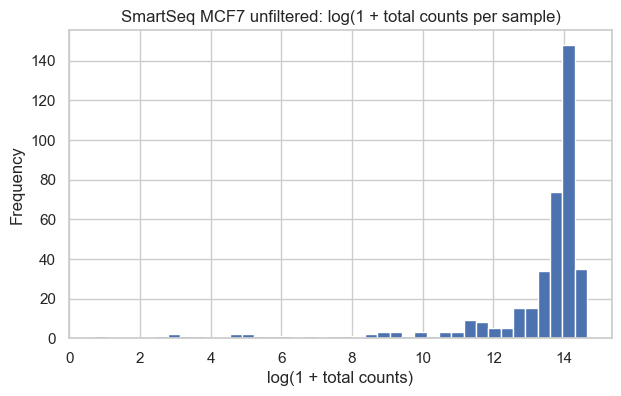

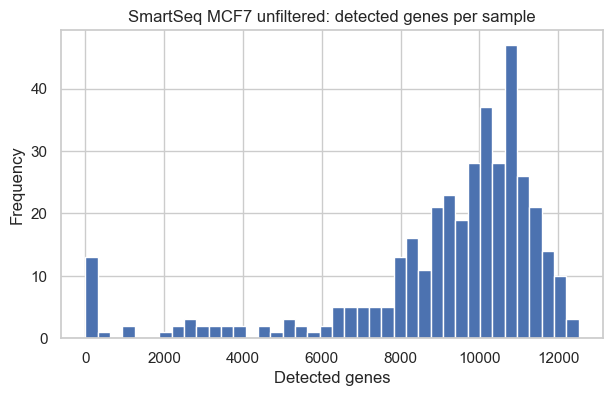

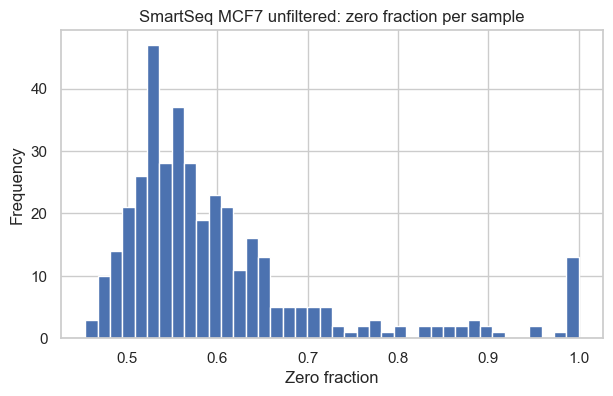

In [97]:
plot_hist(
    np.log1p(qc_mcf7_unf["total_counts"]),
    "SmartSeq MCF7 unfiltered: log(1 + total counts per sample)",
    "log(1 + total counts)"
)

plot_hist(
    qc_mcf7_unf["detected_genes"],
    "SmartSeq MCF7 unfiltered: detected genes per sample",
    "Detected genes"
)

plot_hist(
    qc_mcf7_unf["zero_fraction"],
    "SmartSeq MCF7 unfiltered: zero fraction per sample",
    "Zero fraction"
)

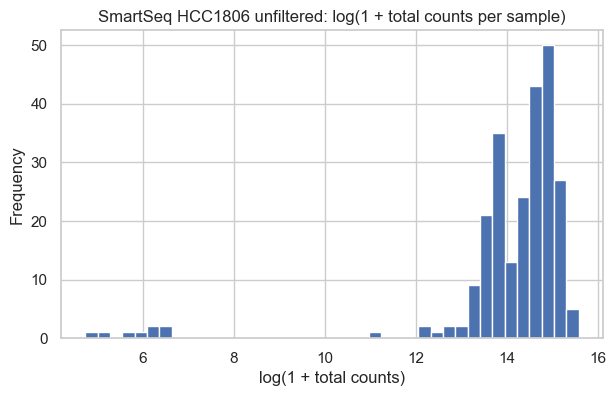

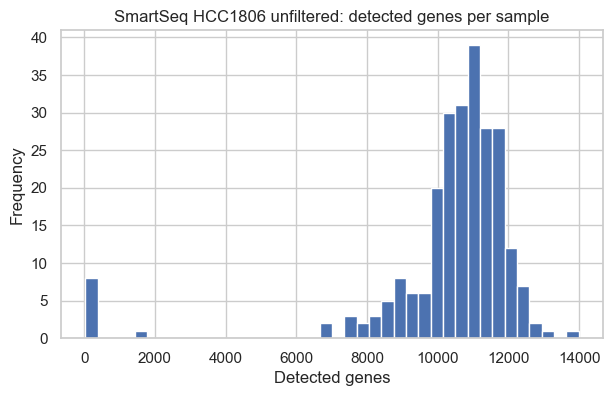

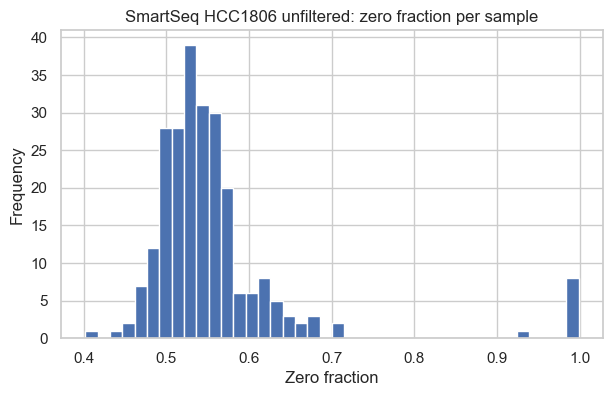

In [98]:
plot_hist(
    np.log1p(qc_hcc_unf["total_counts"]),
    "SmartSeq HCC1806 unfiltered: log(1 + total counts per sample)",
    "log(1 + total counts)"
)

plot_hist(
    qc_hcc_unf["detected_genes"],
    "SmartSeq HCC1806 unfiltered: detected genes per sample",
    "Detected genes"
)

plot_hist(
    qc_hcc_unf["zero_fraction"],
    "SmartSeq HCC1806 unfiltered: zero fraction per sample",
    "Zero fraction"
)

## 10. Quick interpretation of the raw data

The unfiltered SmartSeq data already shows some important issues in the raw gene expression matrices. First, there is a large amount of variation between cells in terms of total counts and number of detected genes. For example, in the MCF7 unfiltered dataset the average number of detected genes per cell is around 9,124, while in HCC1806 it is around 10,330. The total counts also vary a lot across cells, with some cells having extremely low counts and others having very high counts.

Another important point is the high fraction of zero values. The average zero fraction is about 0.60 in MCF7 and about 0.56 in HCC1806, which means that a large part of the matrix is sparse. This is expected in single-cell RNA sequencing data, but it also shows that the raw data contains a lot of noise and many genes are not detected in every cell.

Overall, these results suggest that the raw data is highly heterogeneous and sparse. This helps explain why filtering and normalization are necessary before doing more advanced analyses such as PCA, clustering, or classification.

## 11. Compare unfiltered and filtered SmartSeq data

In [99]:
compare_preprocessing = pd.concat([
    dataset_summary(smart_mcf7_unfiltered, "MCF7 unfiltered"),
    dataset_summary(smart_mcf7_filtered, "MCF7 filtered"),
    dataset_summary(smart_hcc_unfiltered, "HCC1806 unfiltered"),
    dataset_summary(smart_hcc_filtered, "HCC1806 filtered"),
], ignore_index=True)

compare_preprocessing

,dataset,n_genes,n_samples,mean_value,median_value,zero_fraction
0,MCF7 unfiltered,22934,383,43.368444,0.0,0.602153
1,MCF7 filtered,18945,313,61.114583,1.0,0.471576
2,HCC1806 unfiltered,23396,243,86.010698,0.0,0.558456
3,HCC1806 filtered,19503,227,107.439569,3.0,0.452056


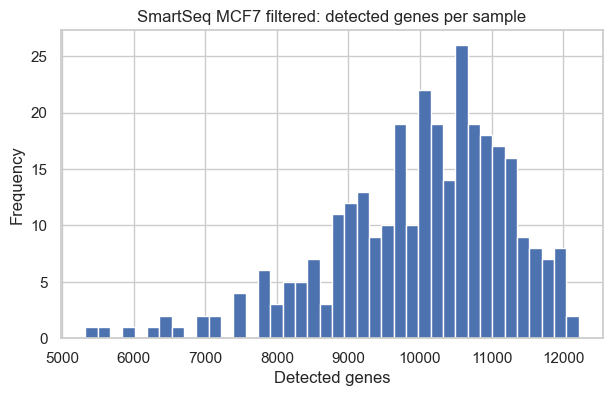

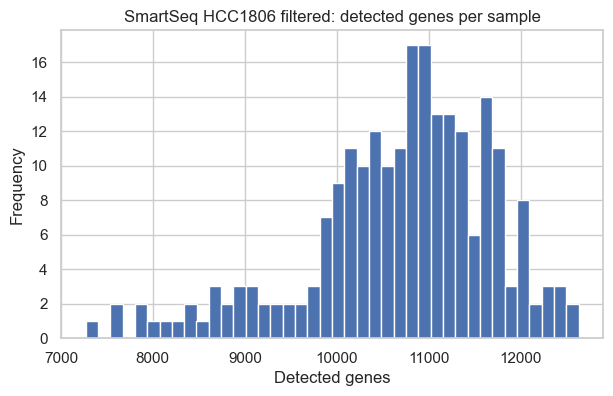

In [100]:
qc_mcf7_filt = sample_qc(smart_mcf7_filtered)
qc_hcc_filt = sample_qc(smart_hcc_filtered)

plot_hist(
    qc_mcf7_filt["detected_genes"],
    "SmartSeq MCF7 filtered: detected genes per sample",
    "Detected genes"
)

plot_hist(
    qc_hcc_filt["detected_genes"],
    "SmartSeq HCC1806 filtered: detected genes per sample",
    "Detected genes"
)

## 12. What filtering seems to do

Comparing the unfiltered and filtered SmartSeq datasets shows that filtering makes the data cleaner and easier to work with. In both cell lines, the number of genes decreases after filtering, which means low-information or rarely detected genes are being removed. At the same time, the median expression value increases from 0 in the unfiltered data to 1 in MCF7 and 3 in HCC1806 after filtering.

Filtering also reduces sparsity. In MCF7, the zero fraction goes from about 0.60 in the unfiltered data to about 0.47 in the filtered data. In HCC1806, it goes from about 0.56 to about 0.45. This means the filtered data contains fewer empty entries and relatively more informative signal.

So, filtering seems to remove part of the noise while keeping the stronger expression patterns. This is useful because it makes the downstream analyses more stable and allows the biological differences between cells to be seen more clearly.

## 13. PCA on normalized SmartSeq data

Now I move to the normalized training data.

This is a better place to look at PCA because normalization reduces some of the technical differences caused by uneven sequencing depth.

I color the PCA plots by condition so I can see whether hypoxia and normoxia separate.

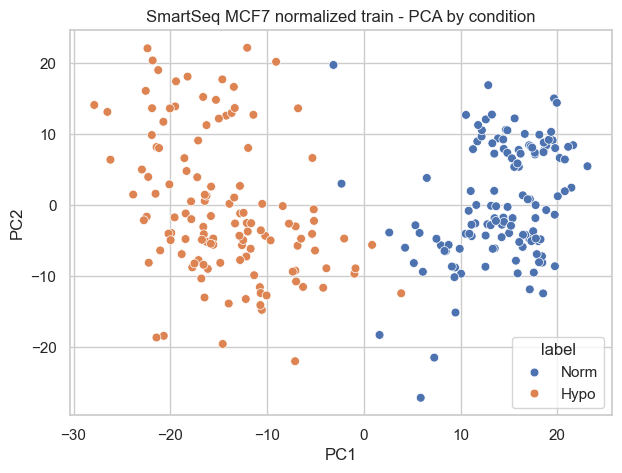

Explained variance ratio: [0.07810178 0.02779398]


In [101]:
pca_plot(
    smart_mcf7_norm_train,
    labels=smart_mcf7_labels,
    title="SmartSeq MCF7 normalized train - PCA by condition"
)

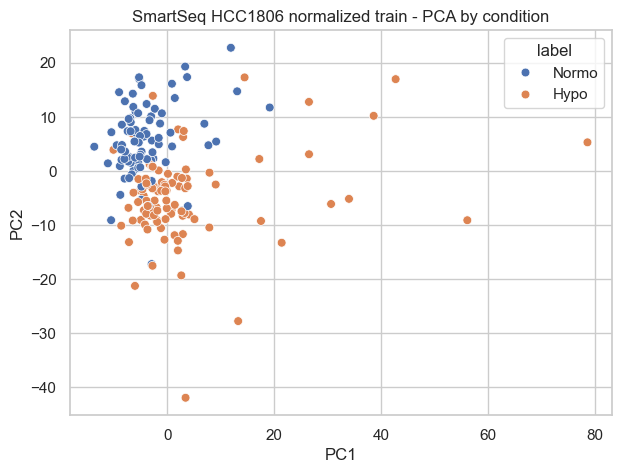

Explained variance ratio: [0.04164704 0.02771966]


In [102]:
pca_plot(
    smart_hcc_norm_train,
    labels=smart_hcc_labels,
    title="SmartSeq HCC1806 normalized train - PCA by condition"
)

## 14. PCA on normalized DropSeq data

Now I do the same thing for DropSeq.

This lets me compare whether the same biological signal is visible in both technologies.

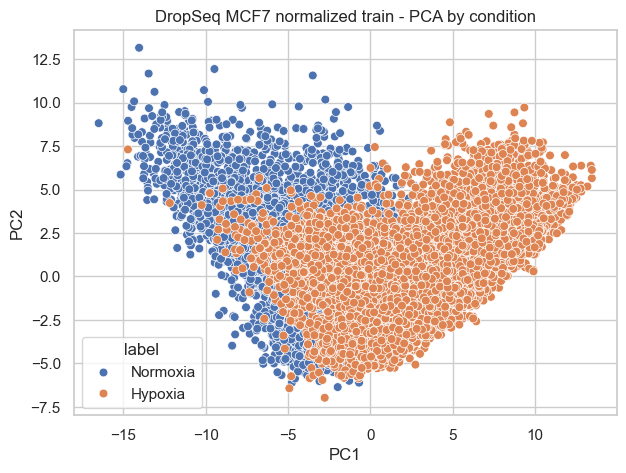

Explained variance ratio: [0.00674412 0.00249983]


In [103]:
pca_plot(
    drop_mcf7_norm_train,
    labels=drop_mcf7_labels,
    title="DropSeq MCF7 normalized train - PCA by condition"
)

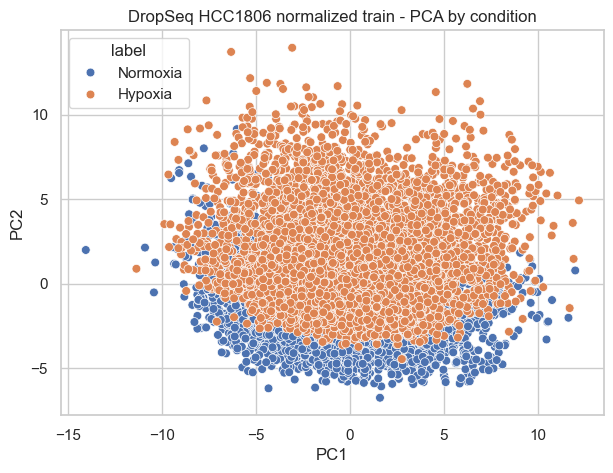

Explained variance ratio: [0.00357671 0.00223465]


In [104]:
pca_plot(
    drop_hcc_norm_train,
    labels=drop_hcc_labels,
    title="DropSeq HCC1806 normalized train - PCA by condition"
)

## 15. PCA interpretation

The PCA plots on the normalized datasets show that the structure of the data is not equally strong across all experiments. In the SmartSeq datasets, the first principal component explains more variation than in the DropSeq datasets. For example, PC1 explains about 7.8% of the variance in SmartSeq MCF7 and about 4.2% in SmartSeq HCC1806, while in DropSeq MCF7 and HCC1806 it explains only about 0.7% and 0.4%, respectively.

This suggests that the SmartSeq data has a stronger visible global structure in the first two principal components, while the DropSeq data is more spread out and less clearly separated in low-dimensional space. A possible reason is that DropSeq contains many more cells and may capture a more complex and diffuse structure, while SmartSeq may produce cleaner separation in the first few components.

Overall, PCA suggests that condition-related structure is present, but its visibility depends on the technology and dataset. In some cases the separation appears stronger, while in others the groups are more mixed, which means that the biological signal may be more subtle or distributed across many dimensions rather than being concentrated in just the first two PCs.

## 16. Heatmaps of the most variable genes

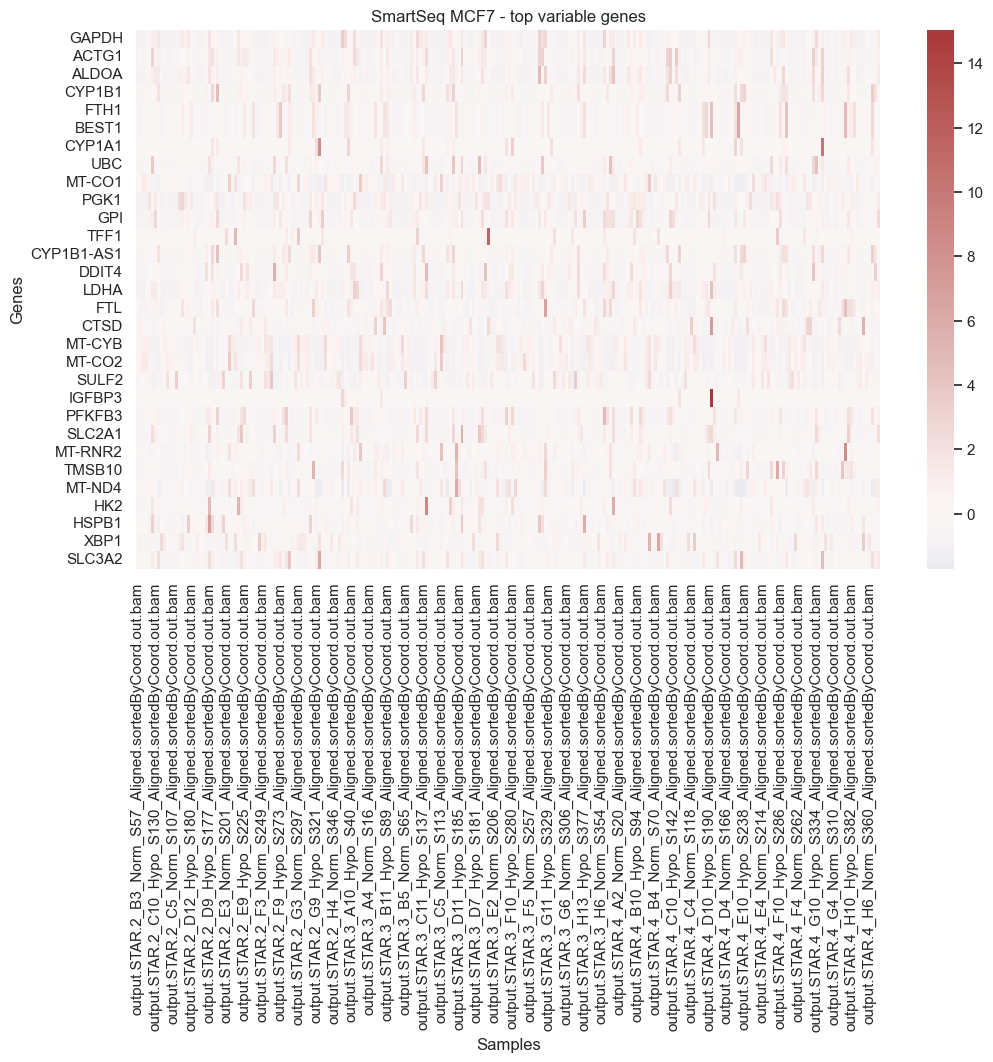

In [105]:
heatmap_top_variable_genes(
    smart_mcf7_norm_train,
    labels=smart_mcf7_labels,
    top_n=30,
    title="SmartSeq MCF7 - top variable genes"
)

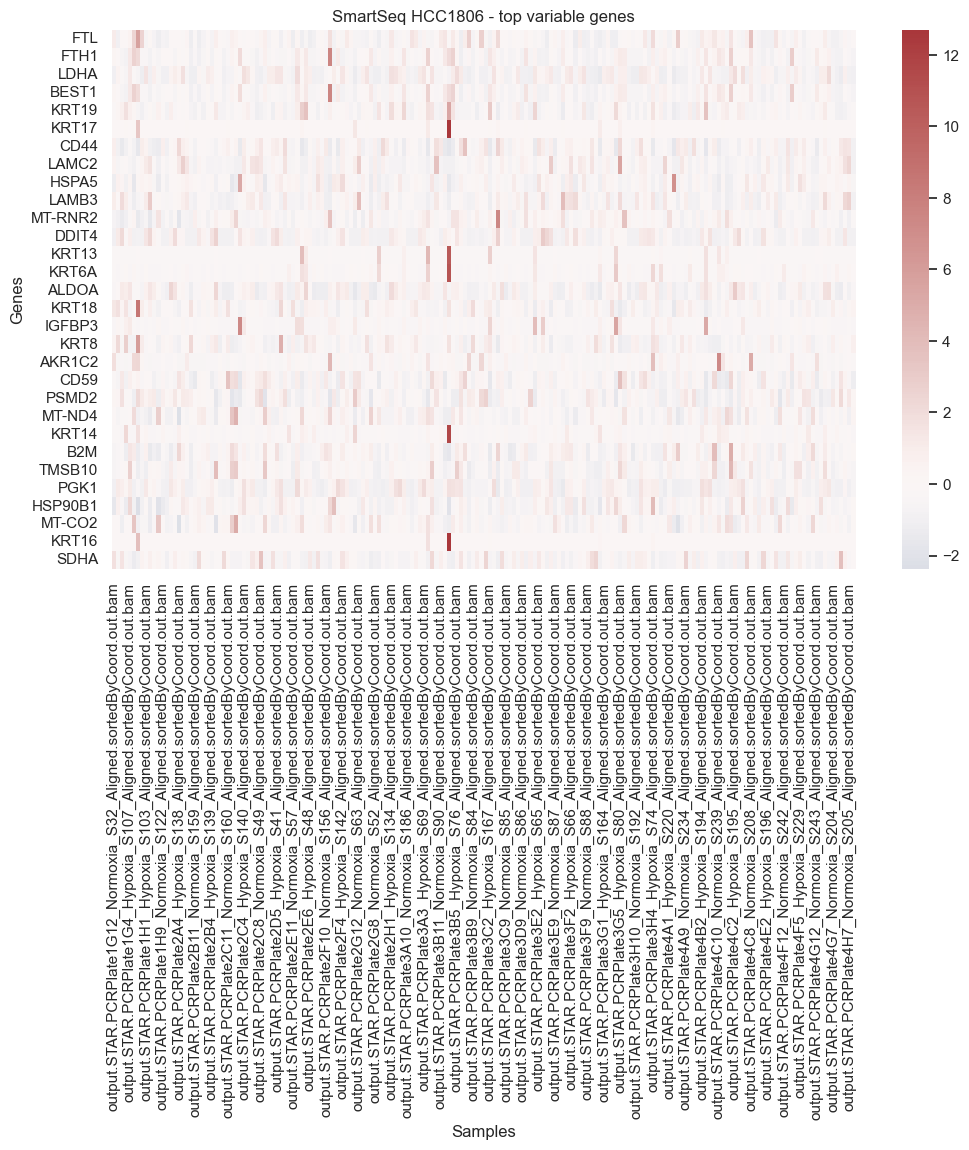

In [106]:
heatmap_top_variable_genes(
    smart_hcc_norm_train,
    labels=smart_hcc_labels,
    top_n=30,
    title="SmartSeq HCC1806 - top variable genes"
)

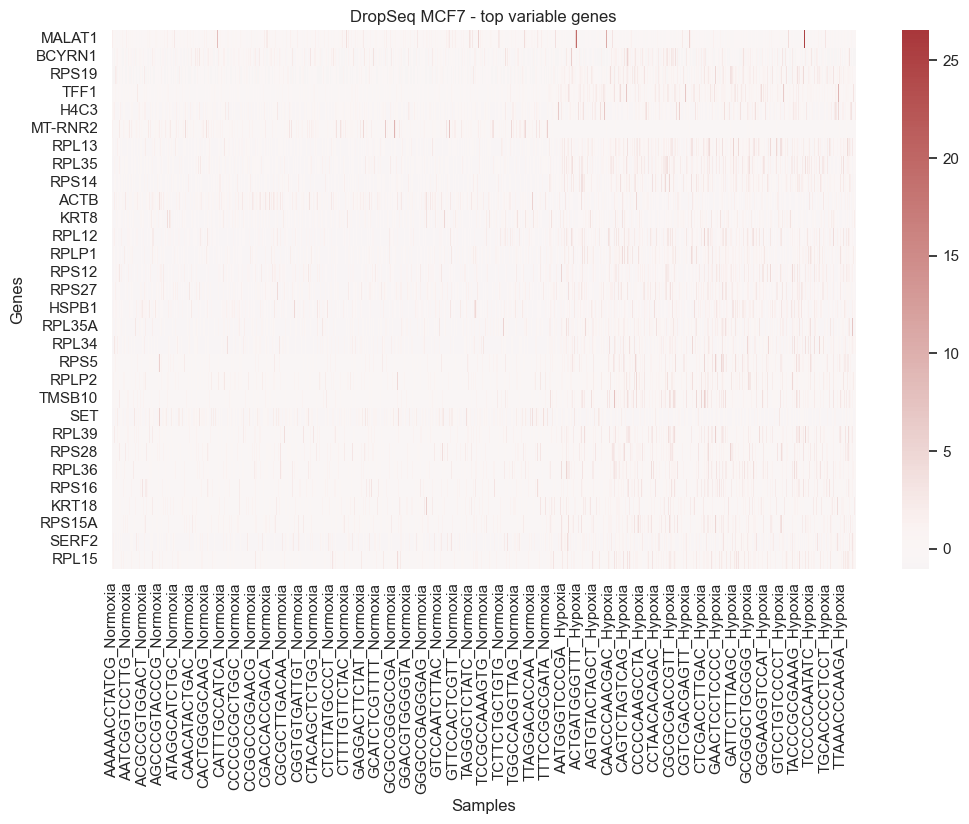

In [107]:
heatmap_top_variable_genes(
    drop_mcf7_norm_train,
    labels=drop_mcf7_labels,
    top_n=30,
    title="DropSeq MCF7 - top variable genes"
)

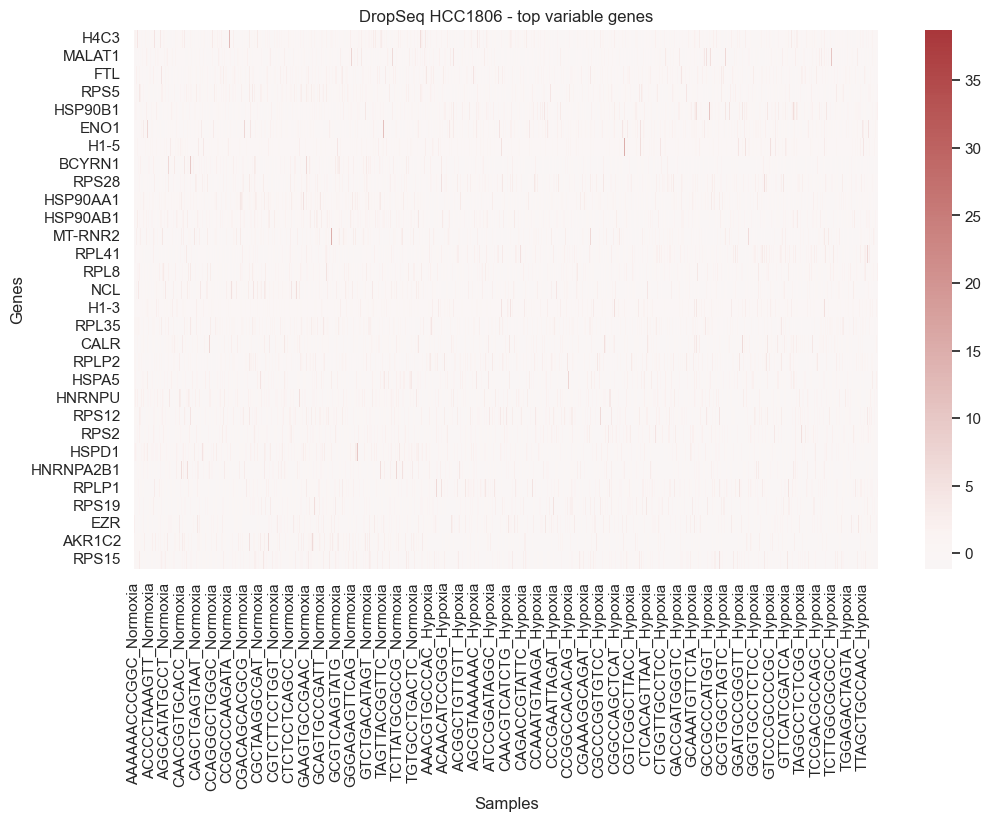

In [108]:
heatmap_top_variable_genes(
    drop_hcc_norm_train,
    labels=drop_hcc_labels,
    top_n=30,
    title="DropSeq HCC1806 - top variable genes"
)

## 17. Compare SmartSeq and DropSeq directly

Now I do one of the most interesting parts of the report.

I compare SmartSeq and DropSeq for the same cell line using the shared genes.

This helps answer:
- do the two technologies produce similar biological structure?
- or does the platform itself create a strong difference?

In [109]:
# MCF7 technology comparison
common_genes_mcf7 = smart_mcf7_norm_train.index.intersection(drop_mcf7_norm_train.index)

mcf7_combined = pd.concat([
    smart_mcf7_norm_train.loc[common_genes_mcf7],
    drop_mcf7_norm_train.loc[common_genes_mcf7]
], axis=1)

mcf7_tech_labels = pd.Series(
    ["SmartSeq"] * smart_mcf7_norm_train.shape[1] + ["DropSeq"] * drop_mcf7_norm_train.shape[1],
    index=mcf7_combined.columns
)

mcf7_cond_labels = pd.concat([smart_mcf7_labels, drop_mcf7_labels])

print(mcf7_combined.shape)

(496, 21876)


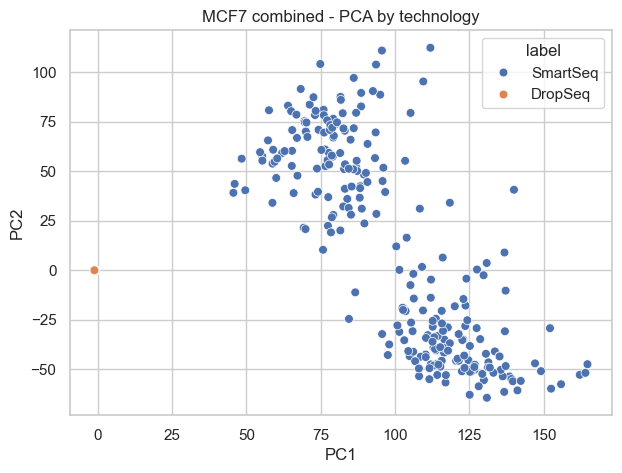

Explained variance ratio: [0.24884558 0.06396284]


In [110]:
pca_plot(
    mcf7_combined,
    labels=mcf7_tech_labels,
    title="MCF7 combined - PCA by technology"
)

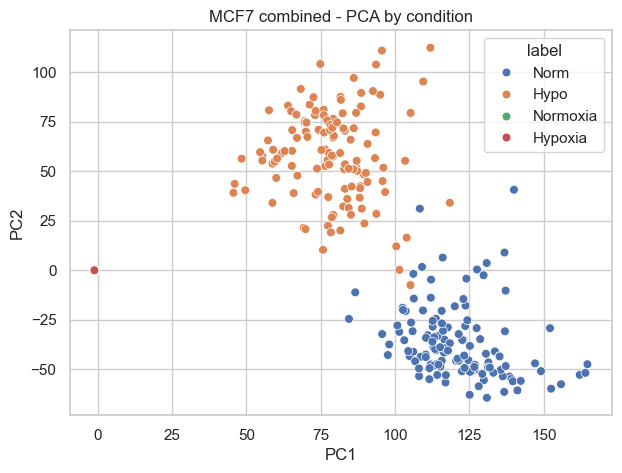

Explained variance ratio: [0.24884558 0.06396284]


In [111]:
pca_plot(
    mcf7_combined,
    labels=mcf7_cond_labels,
    title="MCF7 combined - PCA by condition"
)

In [112]:
# HCC1806 technology comparison
common_genes_hcc = smart_hcc_norm_train.index.intersection(drop_hcc_norm_train.index)

hcc_combined = pd.concat([
    smart_hcc_norm_train.loc[common_genes_hcc],
    drop_hcc_norm_train.loc[common_genes_hcc]
], axis=1)

hcc_tech_labels = pd.Series(
    ["SmartSeq"] * smart_hcc_norm_train.shape[1] + ["DropSeq"] * drop_hcc_norm_train.shape[1],
    index=hcc_combined.columns
)

hcc_cond_labels = pd.concat([smart_hcc_labels, drop_hcc_labels])

print(hcc_combined.shape)

(516, 14864)


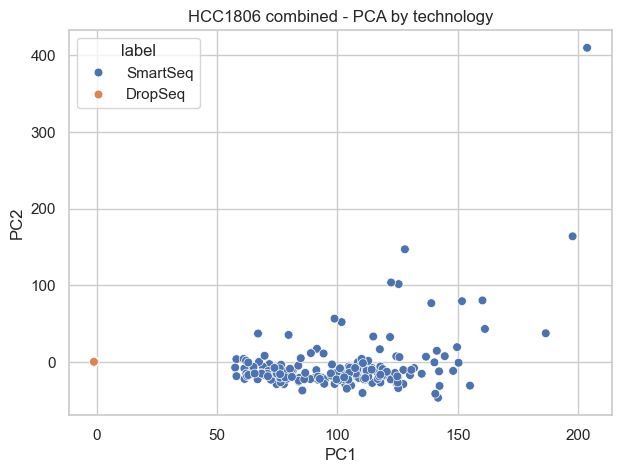

Explained variance ratio: [0.26145437 0.04237131]


In [113]:
pca_plot(
    hcc_combined,
    labels=hcc_tech_labels,
    title="HCC1806 combined - PCA by technology"
)

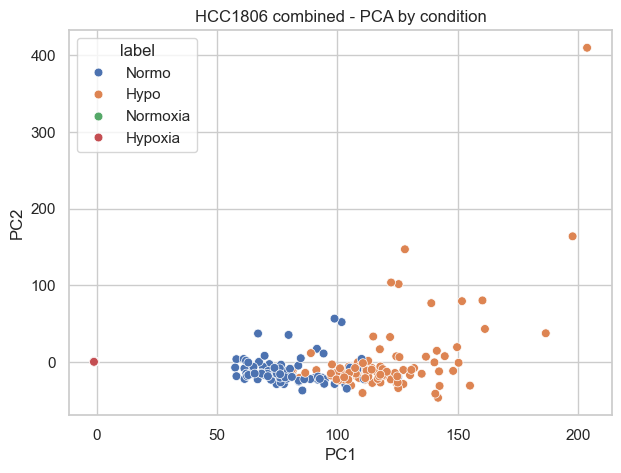

Explained variance ratio: [0.26145437 0.04237131]


In [114]:
pca_plot(
    hcc_combined,
    labels=hcc_cond_labels,
    title="HCC1806 combined - PCA by condition"
)

## 18. Technology comparison interpretation

The combined PCA plots for SmartSeq and DropSeq show a much stronger global structure than the PCA plots within each individual dataset. For MCF7, the first principal component explains about 24.9% of the variance, and for HCC1806 it explains about 26.1%. This is much higher than in the separate PCA analyses, which suggests that sequencing technology introduces a strong source of variation.

This means that when SmartSeq and DropSeq are combined, the platform effect is likely to be one of the main drivers of the separation. In other words, the data structure is influenced not only by biology, such as hypoxia versus normoxia, but also by the sequencing method itself. This is important because it shows that direct comparisons across technologies should be made carefully.

At the same time, condition still matters, but the technology effect seems to be stronger in the combined data. So, these plots suggest that SmartSeq and DropSeq are not perfectly interchangeable, and some of the variation captured by PCA is due to technical differences between the two platforms rather than only biological differences.

## 19. Simple gene-level comparison between conditions

Here I do a very simple comparison:
- average expression in hypoxia
- average expression in normoxia
- difference between them

In [115]:
def simple_condition_comparison(expr, labels):
    labels = labels.loc[expr.columns]
    
    hyp = expr.loc[:, labels.str.contains("Hyp", case=False, na=False)]
    norm = expr.loc[:, labels.str.contains("Norm", case=False, na=False)]
    
    result = pd.DataFrame({
        "mean_hypoxia": hyp.mean(axis=1),
        "mean_normoxia": norm.mean(axis=1)
    })
    
    result["diff"] = result["mean_hypoxia"] - result["mean_normoxia"]
    result["abs_diff"] = result["diff"].abs()
    result = result.sort_values("abs_diff", ascending=False)
    
    return result

In [116]:
mcf7_smart_diff = simple_condition_comparison(smart_mcf7_norm_train, smart_mcf7_labels)
hcc_smart_diff = simple_condition_comparison(smart_hcc_norm_train, smart_hcc_labels)

mcf7_drop_diff = simple_condition_comparison(drop_mcf7_norm_train, drop_mcf7_labels)
hcc_drop_diff = simple_condition_comparison(drop_hcc_norm_train, drop_hcc_labels)

In [117]:
print("Top changing genes in SmartSeq MCF7")
display(mcf7_smart_diff.head(20))

print("Top changing genes in SmartSeq HCC1806")
display(hcc_smart_diff.head(20))

Top changing genes in SmartSeq MCF7


,mean_hypoxia,mean_normoxia,diff,abs_diff
GAPDH,46292.032258,8623.079365,37668.952893,37668.952893
ACTG1,26915.354839,5217.817460,21697.537378,21697.537378
ALDOA,26235.370968,5280.253968,20955.116999,20955.116999
CYP1B1,10696.193548,296.079365,10400.114183,10400.114183
FTH1,10966.370968,3254.865079,7711.505888,7711.505888
PGK1,8696.250000,1379.460317,7316.789683,7316.789683
BEST1,9709.016129,2862.095238,6846.920891,6846.920891
MT-CO1,2497.661290,8972.230159,-6474.568868,6474.568868
GPI,7138.314516,1013.595238,6124.719278,6124.719278
UBC,6946.177419,1625.476190,5320.701229,5320.701229


Top changing genes in SmartSeq HCC1806


,mean_hypoxia,mean_normoxia,diff,abs_diff
LDHA,24055.381443,8955.694118,15099.687326,15099.687326
KRT19,13597.381443,6903.270588,6694.110855,6694.110855
DDIT4,7114.268041,529.011765,6585.256277,6585.256277
ALDOA,10299.670103,4542.941176,5756.728927,5756.728927
FTL,21462.113402,25689.247059,-4227.133657,4227.133657
PGK1,5289.773196,1430.070588,3859.702608,3859.702608
FTH1,13867.432990,11339.929412,2527.503578,2527.503578
ANGPTL4,2261.577320,46.717647,2214.859673,2214.859673
BEST1,12069.711340,9879.823529,2189.887811,2189.887811
HSP90B1,6299.298969,4296.529412,2002.769557,2002.769557


In [118]:
print("Top changing genes in DropSeq MCF7")
display(mcf7_drop_diff.head(20))

print("Top changing genes in DropSeq HCC1806")
display(hcc_drop_diff.head(20))

Top changing genes in DropSeq MCF7


,mean_hypoxia,mean_normoxia,diff,abs_diff
TFF1,3.293241,0.750413,2.542827,2.542827
RPS19,4.048201,1.643684,2.404517,2.404517
MALAT1,2.367672,4.524518,-2.156846,2.156846
RPL13,2.500617,0.931523,1.569094,1.569094
RPL35,2.322385,0.936088,1.386297,1.386297
RPS14,2.147069,0.781897,1.365172,1.365172
MT-RNR2,0.097523,1.379142,-1.281619,1.281619
RPL12,1.685798,0.631090,1.054707,1.054707
TMSB10,1.238426,0.196773,1.041653,1.041653
RPLP1,1.800022,0.820622,0.979401,0.979401


Top changing genes in DropSeq HCC1806


,mean_hypoxia,mean_normoxia,diff,abs_diff
BCYRN1,0.660411,1.619402,-0.958990,0.958990
HSP90AA1,1.185976,2.102888,-0.916912,0.916912
HSP90AB1,1.104956,1.866159,-0.761204,0.761204
MALAT1,1.640634,2.297423,-0.656790,0.656790
AKR1C2,0.350489,1.005015,-0.654526,0.654526
H4C3,3.118890,3.745980,-0.627090,0.627090
NCL,0.806270,1.426941,-0.620671,0.620671
HSPD1,0.559838,1.162545,-0.602707,0.602707
RPL41,1.464547,0.864603,0.599943,0.599943
ENO1,1.724239,1.197130,0.527109,0.527109


## 20. Do the same top genes appear in different datasets?

Here I check whether some of the strongest genes appear again across technologies or cell lines.

That is useful because repeated genes may reflect a more stable biological signal.

In [119]:
top20_mcf7_smart = set(mcf7_smart_diff.head(20).index)
top20_mcf7_drop = set(mcf7_drop_diff.head(20).index)

top20_hcc_smart = set(hcc_smart_diff.head(20).index)
top20_hcc_drop = set(hcc_drop_diff.head(20).index)

print("Overlap MCF7 SmartSeq vs DropSeq:", top20_mcf7_smart.intersection(top20_mcf7_drop))
print("Overlap HCC1806 SmartSeq vs DropSeq:", top20_hcc_smart.intersection(top20_hcc_drop))

Overlap MCF7 SmartSeq vs DropSeq: set()
Overlap HCC1806 SmartSeq vs DropSeq: {'LDHA', 'TMSB10', 'IGFBP3'}


## 21. Train a simple classifier

The instructions mention that normalized data can be used for classifiers.

In [120]:
def prepare_xy(expr, labels):
    X = expr.T.copy()  # samples x genes
    y = labels.loc[X.index].copy()
    
    # make labels simple: Hypoxia = 1, Normoxia = 0
    y = y.astype(str)
    y_bin = y.str.contains("Hyp", case=False, na=False).astype(int)
    
    return X, y_bin

In [121]:
def evaluate_logistic_regression(expr, labels, dataset_name):
    X, y = prepare_xy(expr, labels)
    
    model = LogisticRegression(max_iter=3000)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    
    print(f"{dataset_name}")
    print("CV accuracies:", scores)
    print("Mean CV accuracy:", scores.mean())
    print("-" * 50)
    
    return scores.mean()

In [122]:
results = {}

results["SmartSeq MCF7"] = evaluate_logistic_regression(
    smart_mcf7_norm_train, smart_mcf7_labels, "SmartSeq MCF7"
)

results["SmartSeq HCC1806"] = evaluate_logistic_regression(
    smart_hcc_norm_train, smart_hcc_labels, "SmartSeq HCC1806"
)

results["DropSeq MCF7"] = evaluate_logistic_regression(
    drop_mcf7_norm_train, drop_mcf7_labels, "DropSeq MCF7"
)

results["DropSeq HCC1806"] = evaluate_logistic_regression(
    drop_hcc_norm_train, drop_hcc_labels, "DropSeq HCC1806"
)

SmartSeq MCF7
CV accuracies: [1. 1. 1. 1. 1.]
Mean CV accuracy: 1.0
--------------------------------------------------
SmartSeq HCC1806
CV accuracies: [1.         0.94594595 1.         0.94444444 0.94444444]
Mean CV accuracy: 0.9669669669669669
--------------------------------------------------
DropSeq MCF7
CV accuracies: [0.97480351 0.97872832 0.97780347 0.97849711 0.97942197]
Mean CV accuracy: 0.9778508761380976
--------------------------------------------------
DropSeq HCC1806
CV accuracies: [0.94620361 0.94552264 0.95027248 0.95401907 0.95504087]
Mean CV accuracy: 0.9502117352689865
--------------------------------------------------


In [123]:
pd.DataFrame({
    "dataset": list(results.keys()),
    "mean_cv_accuracy": list(results.values())
}).sort_values("mean_cv_accuracy", ascending=False)

,dataset,mean_cv_accuracy
0,SmartSeq MCF7,1.000000
2,DropSeq MCF7,0.977851
1,SmartSeq HCC1806,0.966967
3,DropSeq HCC1806,0.950212


## 22. Random Forest

I also try a random forest just to compare.

In [124]:
def evaluate_random_forest(expr, labels, dataset_name):
    X, y = prepare_xy(expr, labels)
    
    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    
    print(f"{dataset_name}")
    print("CV accuracies:", scores)
    print("Mean CV accuracy:", scores.mean())
    print("-" * 50)
    
    return scores.mean()

In [125]:
rf_results = {}

rf_results["SmartSeq MCF7"] = evaluate_random_forest(
    smart_mcf7_norm_train, smart_mcf7_labels, "SmartSeq MCF7"
)

rf_results["SmartSeq HCC1806"] = evaluate_random_forest(
    smart_hcc_norm_train, smart_hcc_labels, "SmartSeq HCC1806"
)

rf_results["DropSeq MCF7"] = evaluate_random_forest(
    drop_mcf7_norm_train, drop_mcf7_labels, "DropSeq MCF7"
)

rf_results["DropSeq HCC1806"] = evaluate_random_forest(
    drop_hcc_norm_train, drop_hcc_labels, "DropSeq HCC1806"
)

SmartSeq MCF7
CV accuracies: [1.   1.   1.   0.98 1.  ]
Mean CV accuracy: 0.9960000000000001
--------------------------------------------------
SmartSeq HCC1806
CV accuracies: [1.         0.97297297 1.         1.         0.97222222]
Mean CV accuracy: 0.989039039039039
--------------------------------------------------
DropSeq MCF7
CV accuracies: [0.96740638 0.96578035 0.96439306 0.96462428 0.96901734]
Mean CV accuracy: 0.9662442817858947
--------------------------------------------------
DropSeq HCC1806
CV accuracies: [0.93326524 0.9339462  0.9349455  0.93392371 0.9373297 ]
Mean CV accuracy: 0.9346820700653783
--------------------------------------------------


In [126]:
model_compare = pd.DataFrame({
    "dataset": list(results.keys()),
    "logistic_regression_accuracy": list(results.values()),
    "random_forest_accuracy": [rf_results[k] for k in results.keys()]
})

model_compare

,dataset,logistic_regression_accuracy,random_forest_accuracy
0,SmartSeq MCF7,1.000000,0.996000
1,SmartSeq HCC1806,0.966967,0.989039
2,DropSeq MCF7,0.977851,0.966244
3,DropSeq HCC1806,0.950212,0.934682


## 23. Final discussion

- In this notebook, I looked at gene expression data from 2 cell lines, MCF7 and HCC1806, and from 2 sequencing technologies, SmartSeq and DropSeq.

- The raw SmartSeq data already showed some clear problems, like lots of zero values, big differences between cells, and a lot of variation in total counts and detected genes.

- This is important because it shows why preprocessing is needed before doing more serious analysis. If I used only the raw data, a lot of the patterns could be harder to interpret.

- After filtering, the data became less sparse and easier to work with. The zero fraction dropped in both cell lines, which suggests that filtering removed some of the low-information genes and noise.

- The PCA plots showed that the overall structure is not equally strong in every dataset. SmartSeq had a clearer structure in the first two principal components, while DropSeq looked more spread out.

- This probably means that the signal is easier to see in SmartSeq in low dimensions, while in DropSeq the variation may be more complex and spread across more components.

- When I combined SmartSeq and DropSeq for the same cell line, the PCA separation became much stronger. This suggests that the sequencing technology itself has a big effect on the data.

- So, not all differences in the plots come from biology. Some of them are likely caused by the platform, which means I should be careful when comparing SmartSeq and DropSeq directly.

- The simple gene comparison showed that some genes change a lot between hypoxia and normoxia, but the overlap between technologies was not very large.

- For MCF7, there was no overlap in the top 20 genes between SmartSeq and DropSeq. For HCC1806, there were a few genes in common, like LDHA, TMSB10, and IGFBP3.

- This could mean that some hypoxia-related genes are more stable in HCC1806, or just that MCF7 is more affected by differences between technologies.

- The classification results were still very strong, which means the normalized data clearly contains useful information about the condition.

- Logistic regression performed very well in all datasets, and random forest also gave high accuracy, especially in the SmartSeq datasets.

- Overall, the notebook suggests that both biology and technology matter. The condition signal is definitely there, but the platform also changes the structure of the data quite a lot.

- So the main conclusion is that the normalized datasets are good for exploration and classification, but cross-technology comparisons should be interpreted carefully because some of the separation may come from technical differences and not only from biology.